# Mini-Batch Gradient Descent for Linear Regression – Theory & Derivation

## 1. Model Representation (Vectorized Form)

We consider a linear regression model with one feature $x$ and target $y$.  
To handle the bias term $b$ in a matrix-friendly way, we augment the feature matrix with a column of ones.  
Let:

- $X_{\text{design}}$ : $m \times 2$ matrix where the first column is all $1$s and the second column contains the feature values.
- $\theta = \begin{bmatrix} b \\ w \end{bmatrix}$ : parameter vector (bias and weight).

The prediction for the entire dataset is:

$$
\mathbf{y}_{\text{pred}} = X_{\text{design}} \, \theta
$$

## 2. Mini‑Batch Setup

Instead of using all $m$ samples at once, we randomly split the data into small **batches** of size $B$ (e.g., $B = 20$).  
For a given batch:

- $X_b$ : $B \times 2$ design matrix (including the ones column)
- $\mathbf{y}_b$ : $B \times 1$ vector of true target values

The batch prediction is:

$$
\mathbf{y}_{\text{pred}}^{(b)} = X_b \, \theta
$$

## 3. Cost Function for a Mini‑Batch

We use the **Mean Squared Error (MSE)** averaged over the batch:

$$
J_b(\theta) = \frac{1}{B} \sum_{i=1}^{B} \left( y_{\text{pred}}^{(i)} - y^{(i)} \right)^2
$$

In vector notation, defining the error vector $\mathbf{e} = \mathbf{y}_{\text{pred}}^{(b)} - \mathbf{y}_b$, this becomes:

$$
J_b(\theta) = \frac{1}{B} \, \mathbf{e}^T \mathbf{e}
$$

## 4. Gradient Derivation

We need the gradient $\nabla_\theta J_b(\theta)$ to update $\theta$ in the direction that reduces the error.

Let $\mathbf{e} = X_b\theta - \mathbf{y}_b$. Then:

$$
J_b(\theta) = \frac{1}{B} (X_b\theta - \mathbf{y}_b)^T (X_b\theta - \mathbf{y}_b)
$$

Taking the derivative w.r.t. $\theta$ (using matrix calculus rules):

$$
\frac{\partial J_b}{\partial \theta} = \frac{2}{B} X_b^T (X_b\theta - \mathbf{y}_b)
$$

Thus:

$$
\nabla_\theta J_b = \frac{2}{B} X_b^T (\mathbf{y}_{\text{pred}}^{(b)} - \mathbf{y}_b)
$$

> **Note:** In the code, the `calculate_gradient` function returns `(1/B) * np.dot(X_b.T, b_error)`, i.e., it omits the factor $2$. This is equivalent to absorbing the factor $2$ into the learning rate $\alpha$. Both forms are correct as long as the learning rate is tuned accordingly.

## 5. Parameter Update Rule

With learning rate $\alpha > 0$, the mini‑batch gradient descent update is:

$$
\theta := \theta - \alpha \; \nabla_\theta J_b
$$

Substituting the gradient:

$$
\theta := \theta - \alpha \cdot \frac{2}{B} X_b^T (\mathbf{y}_{\text{pred}}^{(b)} - \mathbf{y}_b)
$$

In the code, the update is implemented as:

```python
gradient = calculate_gradient(y_pred, y_batch, X_batch, batch_size)
theta -= alpha * gradient

In [16]:
import numpy as np
import matplotlib.pyplot as plt 
import warnings 

# What MSE Loss and the Gradient Tell Us

## The Goal of Training

In mini‑batch gradient descent, we repeatedly adjust the model parameters (bias $b$ and weight $w$) so that predictions $\hat{y}$ get closer to the true targets $y$.  
To do this, we need two things:

1. A **measure** of how wrong the model currently is.
2. A **direction** to move the parameters to make it less wrong.

That is exactly what this module provides.

---

## 1. Mean Squared Error (MSE) Loss

### What it computes:
The average squared difference between predictions and true values over the current mini‑batch:

$$
\text{MSE} = \frac{1}{B} \sum_{i=1}^{B} (\hat{y}^{(i)} - y^{(i)})^2
$$

### What it tells us:
- A **small MSE** means the model’s predictions are close to the true values → the model is performing well.
- A **large MSE** means the model is far off → it needs to improve.

### Why squaring?
- Errors become positive, so over‑predictions and under‑predictions do not cancel.
- Large errors are penalised more heavily, forcing the model to avoid big mistakes.

### What we learn from tracking MSE over epochs:
- **Decreasing loss** → the model is learning.
- **Loss stagnates** → the model has converged (minimum reached).
- **Loss increases** → something is wrong (e.g., learning rate too high).

---

## 2. Gradient of the Loss

### What it computes:
The derivative of the MSE loss with respect to each parameter.  
For linear regression with one feature, we have two parameters: bias $b$ and weight $w$.  
The gradient is a vector:

$$
\nabla = \begin{bmatrix} \frac{\partial \text{MSE}}{\partial b} \\[4pt] \frac{\partial \text{MSE}}{\partial w} \end{bmatrix}
$$

In vectorized form for a mini‑batch:

$$
\nabla = \frac{2}{B} \, X_b^T \, (\hat{y}_b - y_b)
$$

where $X_b$ is the design matrix (first column all ones, second column the feature values).

### What the gradient tells us:
- **Sign of each component** indicates the direction of steepest *increase* of the loss:
  - Positive gradient → increasing the parameter makes the loss larger → we should **decrease** the parameter.
  - Negative gradient → increasing the parameter makes the loss smaller → we should **increase** the parameter.
- **Magnitude** indicates how sensitive the loss is to that parameter. Larger magnitude means that parameter needs a bigger change.

### Intuitive interpretation for each parameter:

- **Gradient with respect to bias ($b$)** :  
  It is proportional to the **sum of the errors** in the batch. If most predictions are too high (positive errors), the bias needs to go down.

- **Gradient with respect to weight ($w$)** :  
  It is proportional to the **sum of error × feature value**. If a large positive feature $x$ comes with a positive error, the weight should be decreased strongly; if the error is negative, the weight should be increased.

### Why we need the gradient:
The gradient tells us **how to change $b$ and $w$** to reduce the loss.  
Once we have the gradient, the update rule is simple:

$$
b_{\text{new}} = b_{\text{old}} - \alpha \cdot \text{grad}_b
$$
$$
w_{\text{new}} = w_{\text{old}} - \alpha \cdot \text{grad}_w
$$

where $\alpha$ is the learning rate (step size).

---

## Summary

| Concept | What it gives you | What it tells you |
|---------|-------------------|--------------------|
| **MSE Loss** | A single number | How wrong the model is (error magnitude) |
| **Gradient** | A vector of slopes | Which direction to move each parameter to reduce the error |

Together, they are the engine of gradient descent: **measure the error, then move downhill**.

In [17]:
# ======================================
# MODULE : 1 GRADIENT & MSE LOSS
# ======================================

def calculate_gradient(y_pred, y_b, X_b, B):
    
    #Error in prediction 
    b_error = y_pred - y_b
    
    #Gradient for mini-batch 
    mini_gradient = (2.0/B) * np.dot(X_b.T, b_error)
    
    return mini_gradient

def mse_loss(y_pred,y):
    
    return np.mean((y_pred - y)**2)
 

In [18]:

# =====================================================================
# MODULE 2: MINI-BATCH GRADIENT DESCENT FUNCTION
# =====================================================================

def train_mini_batch(X, y, alpha, batch_size, epochs):
    
    #Number of samples(training data) data in X
    m_samples = X.shape[0]
    
    #Adding a leading coloumns of Ones to handle bias(b) in X Matrix
    X_design = np.hstack( (np.ones( (m_samples,1) ),X))
    
    #Initializing parameter vector theta with zeros e.g. [b,w]^T ---->shape [2x1]
    theta = np.zeros(( 1 + X.shape[1],1))
    
    #calculating the Number of batchs
    num_batches = m_samples // batch_size
    
    #Accumulating lost history duing training
    loss_hist = []
    
    print("--- Starting Mini-Batch SGD Training ---")
    print(f"Batch Size: {batch_size} | Total Full Batches per Epoch: {num_batches}\n")
    
    for epoch in range(1, epochs+1):
        
        #A. Shuffling the global feature and target in perfect unison per epoch pass
        
        indices = np.arange(m_samples)# Creates: [0, 1, 2, 3, ..., 99]
        np.random.shuffle(indices)# Randomizes it in-place: [47, 12, 89, 3, ..., 51]
        
        X_shuff = X_design[indices]# Reorders X_design rows using the shuffled indices
        y_shuff = y[indices]# Reorders y using the SAME shuffled indices (keeps alignment!)
        
        #B. Looping thorugh mini-batches 
        
        for b_indx in range(num_batches):
            
            #slicing range for given batch size
            start_row = b_indx * batch_size
            end_row = start_row + batch_size
            
            #slice out current mini-batch sub-matrix
            X_batch = X_shuff[start_row : end_row]# size :[Bx2]
            y_batch = y_shuff[start_row : end_row]# size :[Bx1]
            
            #computing Vectorized batch predictions  
            y_pred = np.dot(X_batch,theta)
            
            #calculating gradient
            gradient = calculate_gradient(y_pred, y_batch, X_batch, batch_size)
            
            #overwriting parameter corrdinates downhill
            theta -= alpha * gradient
        
        #C. Handles Remainder data(The uneven tail)
        if m_samples % batch_size !=0:
            # Check if there's a remainder (NOT evenly divisible)
            # Example: 105 samples ÷ 20 batch_size = 5 batches with 5 remainder
            
            start_row = num_batches * batch_size
            # If num_batches=5, batch_size=20: start_row = 100
            
            X_remain = X_shuff[start_row:]
            y_remain = y_shuff[start_row:]
            
            #Remainder bacth-size, It Count how many leftover samples (e.g., 5)
            B_remain_size = X_remain.shape[0]
            
            #Predicting target y in remaining data
            y_pred_remain = np.dot(X_remain,theta)
            
            #calculating the gradient
            gradient_remain = calculate_gradient(y_pred_remain, y_remain, X_remain, B_remain_size)
            
            #overwriting parameter corrdinates downhill 
            theta -= alpha * gradient_remain
            
        #D. Calculating all evaluation losses
        epoch_prediction = np.dot(X_design, theta)
        loss = mse_loss(epoch_prediction, y)
        loss_hist.append(loss)
        """
        if epoch == 1 or epoch % 100 == 0:
            print(f"Epoch: {epoch:02d} | MSE Loss: {loss:.4f} ") """
            
    return theta, loss_hist 

       
    

Shape of X :(105, 1) and y :(105, 1)


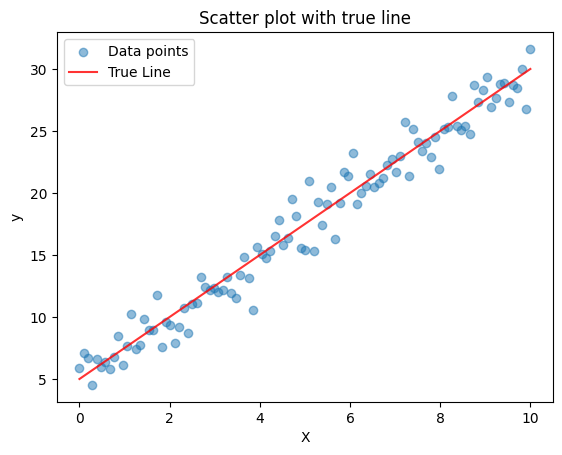

In [19]:
# =========================================================
# MODULE 3: GENRATING SYNTHETIC FEATURE X AND TARGET Y
# =========================================================

np.random.seed(46) #To get the same value every time

#Feature X
X=np.linspace(0,10,105)

#Trure weight w and bias
t_w,t_b=2.5,5.0

#Adding randomness 
noise = np.random.normal(0,1.5,size=(len(X)))

#Target values
y = t_w*X + t_b +noise

#Reshaping the raw 1D date into explicit 2D Matrix of [m x 1]
X_global = X.reshape(-1,1)
y_global = y.reshape(-1,1)# -1 to let NumPy calculate one dimension automatically
print(f"Shape of X :{X_global.shape} and y :{y_global.shape}")

#Visulization
plt.scatter(X,y,alpha=0.5,label='Data points')
plt.plot(X,t_w*X + t_b,alpha=0.8,label="True Line",color='red')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Scatter plot with true line')
plt.legend()
plt.show()

In [20]:
# =====================================================================
# MODULE 4: EXECUTION & HYPERPARAMETERS
# =====================================================================
learning_rate = 0.01
batch_size_setting = 20  # Groups of 20 rows (Creates exactly 5 batches per epoch)
total_epochs = 400

# Train the model
final_theta, loss_trace = train_mini_batch(X_global, y_global, learning_rate, batch_size_setting, total_epochs)

print("\n--- Training Completed Successfully ---")
print(f"True Underlying Model Target: w = {t_w:.1f}, b = {t_b:.1f}")
print(f"Mini-Batch Final Output Line: w = {final_theta[1,0]:.3f}, b = {final_theta[0,0]:.3f}")

--- Starting Mini-Batch SGD Training ---
Batch Size: 20 | Total Full Batches per Epoch: 5


--- Training Completed Successfully ---
True Underlying Model Target: w = 2.5, b = 5.0
Mini-Batch Final Output Line: w = 2.490, b = 4.954


--------------------------------------------------------------------------------
--- Starting Mini-Batch SGD Training ---
Batch Size: 10 | Total Full Batches per Epoch: 10

For Learning rate: 0.0001
converges slowly and may still be far from optimum after 400 iterations. (stable but slower convergence)

--- Training Completed Successfully ---
True Underlying Model Target: w = 2.5, b = 5.0
Mini-Batch Final Output Line: w = 3.028, b = 1.356
--------------------------------------------------------------------------------
--- Starting Mini-Batch SGD Training ---
Batch Size: 10 | Total Full Batches per Epoch: 10

For Learning rate: 0.01
Learning rate is good and model converges nicely. (good convergence)

--- Training Completed Successfully ---
True Underlying Model Target: w = 2.5, b = 5.0
Mini-Batch Final Output Line: w = 2.523, b = 4.954
--------------------------------------------------------------------------------
--- Starting Mini-Batch SGD Training ---
Batch Size: 10 | Total Full Ba

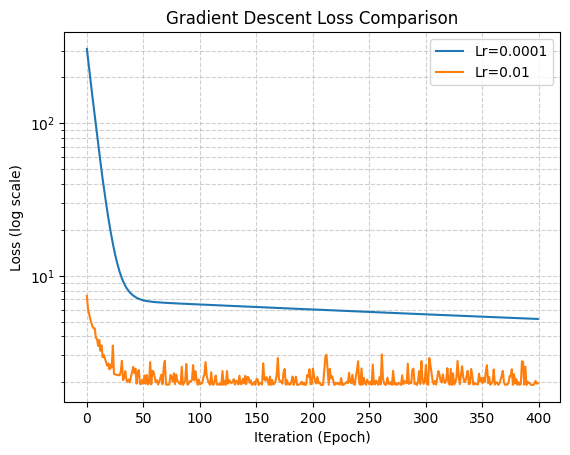

In [21]:

# =======================================================================
# MODULE 5: INITIALIZATION FOR TRAINING (CHECKING DIFFRENT LEARNING RATE)
# =======================================================================
learning_rate = [0.0001, 0.01, 0.25]
total_epochs = 400
batch_size_setting = 10 

fig, ax = plt.subplots()
print("----" * 20)

for i in range(len(learning_rate)):
    
    
    # Running model for different learning rate
    final_theta, loss_trace = train_mini_batch(X_global, y_global, learning_rate[i], batch_size_setting, total_epochs)
    b_final = final_theta[0,0]
    w_final = final_theta[1,0]
    
    print(f"For Learning rate: {learning_rate[i]}")
    

    if np.isnan(w_final) or np.isnan(b_final):
        print("Learning rate is too high makes the model diverge. (unstable divergence)")
        warnings.filterwarnings("ignore", category=RuntimeWarning) # Ignore warnings as w=nan, b=nan
        
    elif abs(t_w - w_final) < 1e-1 or abs(t_b - b_final) < 1e-1:
        
        print("Learning rate is good and model converges nicely. (good convergence)")
        ax.plot(range(total_epochs), loss_trace, '-', label=f"Lr={learning_rate[i]}")
        
    else:
        print(f"converges slowly and may still be far from optimum after {total_epochs} iterations. (stable but slower convergence)")
        ax.plot(range(total_epochs), loss_trace, '-', label=f"Lr={learning_rate[i]}")        
        
    print("\n--- Training Completed Successfully ---")
    print(f"True Underlying Model Target: w = {t_w:.1f}, b = {t_b:.1f}")
    print(f"Mini-Batch Final Output Line: w = {final_theta[1,0]:.3f}, b = {final_theta[0,0]:.3f}")
    print("----" * 20)

ax.set_yscale('log')
ax.set_xlabel('Iteration (Epoch)')
ax.set_ylabel('Loss (log scale)')
ax.set_title('Gradient Descent Loss Comparison')
ax.grid(True, which='both', linestyle='--', alpha=0.6)
ax.legend()
plt.show()



# Understanding Hyperparameters: Learning Rate, Batch Size, and Epochs

In the module above, we experiment with different **learning rates** while keeping **batch size** and **number of epochs** fixed. This helps us see how each hyperparameter influences the training process. Below is the intuition behind each one.

---

## 1. Learning Rate ($\alpha$)

The learning rate controls how large a step we take downhill along the gradient.  
It is the most critical hyperparameter for gradient descent.

### What the code shows (three regimes):

| Learning Rate | Behavior | What it means |
|---------------|----------|----------------|
| **Very small** (e.g., 0.0001) | Loss decreases very slowly; after many epochs the model is still far from the true parameters. | The model learns **too cautiously** – it will eventually converge, but may need thousands of epochs. |
| **Moderate** (e.g., 0.01) | Loss decreases steadily and reaches a low value; final parameters are close to the true values. | The **optimal range** – the model learns efficiently and converges well. |
| **Too large** (e.g., 0.25) | Loss explodes or becomes `NaN`; parameters diverge to infinity. | The model **overshoots** the minimum and becomes unstable. This is called *divergence*. |

### Intuition:
- Imagine you are at the top of a valley and want to reach the bottom.  
  - **Small learning rate** → tiny baby steps → you will eventually get there, but very slowly.  
  - **Good learning rate** → confident steps → you reach the bottom quickly.  
  - **Large learning rate** → giant leaps → you jump over the valley and end up on the opposite slope, or even fly off the mountain.

### Effect on prediction:
- Too small → underfitting (high bias), because training is incomplete.  
- Too large → unstable predictions (sometimes extreme values, `NaN`).  
- Just right → predictions closely follow the true underlying line.

---

## 2. Batch Size

In the code, `batch_size_setting = 10` is used for the learning rate comparison. If we change the batch size while keeping learning rate and epochs fixed, what happens?

### Intuition:

| Batch Size | Effect on Gradient Estimate | Effect on Training |
|------------|-----------------------------|--------------------|
| **Small** (e.g., 1, pure SGD) | High variance, noisy gradient | Converges **faster per iteration** (more updates per epoch) but jumps around a lot. Final model may be slightly less accurate. |
| **Medium** (e.g., 10–100) | Balanced noise vs. computation | Smooth and efficient convergence. Most common choice. |
| **Large** (e.g., full batch) | Very accurate gradient (low variance) | Each update is costly (one big matrix multiplication). May get stuck in sharp minima. |

### Why batch size matters:
- **Small batch** → more updates per epoch, each update is noisy → can escape shallow local minima (good for non‑convex problems) but may not settle exactly at the bottom.  
- **Large batch** → each update is a better estimate of the true gradient, but computationally heavier and may lead to **overfitting** (the model memorizes the data rather than generalising).

### Keeping other factors fixed:
If you fix learning rate and epochs, increasing batch size means:
- Fewer parameter updates per epoch (since there are fewer batches).  
- The gradient is less noisy, so the path is smoother but may be slower in wall‑clock time.

---

## 3. Number of Epochs

An **epoch** is one complete pass through the entire training dataset.  
In the code, `total_epochs = 400` is fixed for all learning rate tests.

### Intuition:

| Number of Epochs | Effect |
|------------------|--------|
| **Too few** | Model **underfits** – it hasn’t seen the data enough times to learn the pattern. Predictions are poor. |
| **Enough** | Loss stops decreasing (convergence). The model has learned the underlying relationship. |
| **Too many** (with fixed learning rate) | Waste of computation; after convergence, the loss no longer improves. May start **overfitting** if the model is complex (though for linear regression, overfitting is rare). |

### How epoch count interacts with learning rate:
- With a **small learning rate**, you need **more epochs** to converge.  
- With a **good learning rate**, fewer epochs are enough.  
- With a **large learning rate**, more epochs won’t help – the model never converges.

### In the code:
We run all three learning rates for the **same 400 epochs**. This allows a fair comparison:  
- For `lr=0.0001`, 400 epochs are **not enough** – the loss is still decreasing slowly.  
- For `lr=0.01`, 400 epochs are **sufficient** – convergence is reached.  
- For `lr=0.25`, the model diverges immediately; increasing epochs would only make the numbers larger (or `NaN`).

---

## Summary Table: How Each Hyperparameter Affects Prediction

| Hyperparameter | Small Value | Optimal Value | Large Value |
|----------------|-------------|---------------|--------------|
| **Learning Rate** | Slow convergence, underfitted predictions | Fast convergence, accurate predictions | Divergence, `NaN` predictions |
| **Batch Size** | Noisy updates, possibly lower final accuracy | Smooth updates, good generalisation | Smooth but computationally heavy, may overfit |
| **Number of Epochs** | Underfitted predictions | Converged, accurate predictions | Wasted computation, no improvement |

---

## Remarks

The learning rate is **the most sensitive** hyperparameter.  
**Batch size** controls the trade‑off between update speed and gradient accuracy.  
**Number of epochs** must be large enough for the model to converge, but not unnecessarily large.

In practice, you often:
1. Choose a moderate batch size (e.g., 32, 64, or 128).  
2. Tune the learning rate by running a few epochs with different values (as done in this module).  
3. Increase the number of epochs until the loss stabilises.

--- Starting Mini-Batch SGD Training ---
Batch Size: 10 | Total Full Batches per Epoch: 10



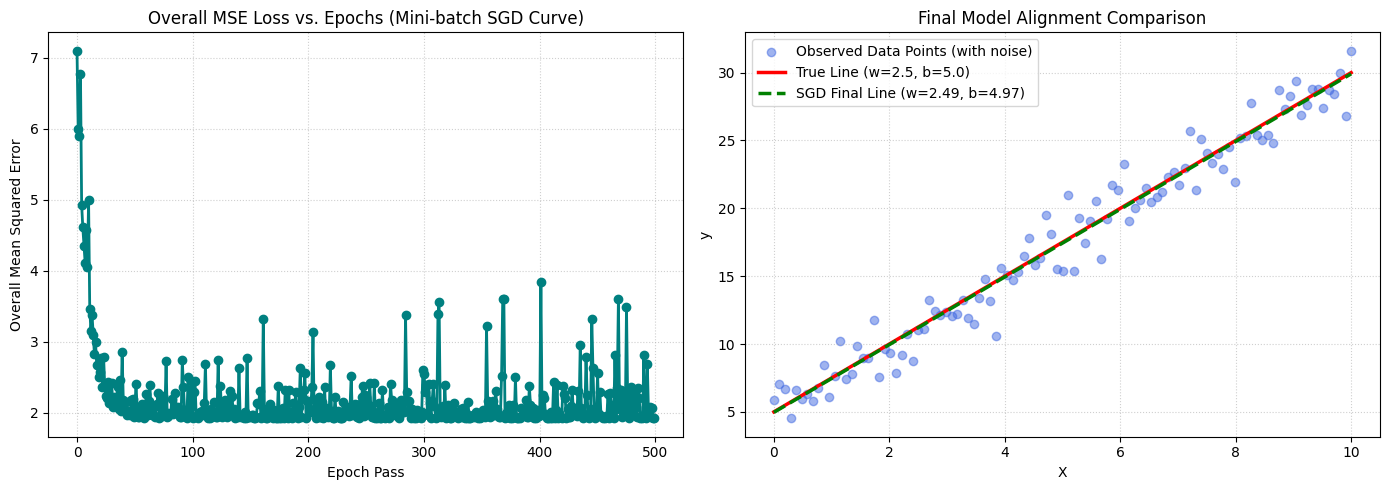

In [22]:

# ======================================================
# MODULE 6: VISUALIZING SGD CONVERGENCE & FINAL FIT
# ======================================================

learning_rate = 0.01
batch_size_setting = 10  # Groups of 20 rows (Creates exactly 5 batches per epoch)
total_epochs = 500

# Train the model
final_theta, loss_trace = train_mini_batch(X_global, y_global, learning_rate, batch_size_setting, total_epochs)
b_final = final_theta[0,0]
w_final = final_theta[1,0]

#visualisation of model prediction and loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Loss Curve (Watching the error bowl drain)
ax1.plot(range(total_epochs), loss_trace, color='teal', marker='o', linewidth=2)
ax1.set_xlabel('Epoch Pass')
ax1.set_ylabel('Overall Mean Squared Error')
ax1.set_title('Overall MSE Loss vs. Epochs (Mini-batch SGD Curve)')
ax1.grid(True, linestyle=':', alpha=0.6)

# Plot B: Final Regression Fit against true underlying line
ax2.scatter(X, y, alpha=0.5, color='royalblue', label='Observed Data Points (with noise)')
ax2.plot(X, t_w*X + t_b, color='red', linewidth=2.5, label=f'True Line (w={t_w}, b={t_b})')
ax2.plot(X, w_final*X + b_final, color='green', linestyle='--', linewidth=2.5, label=f'SGD Final Line (w={w_final:.2f}, b={b_final:.2f})')
ax2.set_xlabel('X')
ax2.set_ylabel('y')
ax2.set_title('Final Model Alignment Comparison')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


#  Observation and Findings

After tuning the hyperparameters, we train the model one last time with a well‑chosen learning rate (`0.01`), a fixed batch size (`10`), and enough epochs (`500`).  
Then we create **two plots** that tell us everything about the training process and the final model quality.

---

## Plot 1: Loss Curve (Left)

**What is shown:**  
The overall Mean Squared Error (MSE) on the **entire dataset** after each epoch, plotted against the number of epochs.

**What it tells us:**

- **At the start (epoch 0)** → Loss is high. The initial random parameters ($b=0$, $w=0$) produce poor predictions.
- **As epochs increase** → Loss decreases rapidly at first, then slowly flattens. This is the classic *learning curve* of gradient descent.
- **After ~200–300 epochs** → Loss stabilises (converges). Further epochs bring negligible improvement.
- **Shape of the curve** → Smooth, downward trend with small fluctuations (due to mini‑batch sampling noise). No spikes or `NaN` values, indicating stable training.

**Key insight:**  
The model successfully minimises the error. The chosen learning rate (`0.01`) is neither too small (which would cause a very slow, linear drop) nor too large (which would cause divergence).

---

## Plot 2: Final Regression Fit (Right)

**What is shown:**  
- **Blue dots** – The noisy synthetic data points (true underlying line + random noise).  
- **Red solid line** – The true underlying model: $y = 2.5x + 5.0$.  
- **Green dashed line** – The learned model after 500 epochs of mini‑batch SGD.

**What it tells us:**

- The green dashed line **almost perfectly overlaps** the red solid line. The learned parameters are:
  - $w_{\text{final}} \approx 2.5$ (true weight)
  - $b_{\text{final}} \approx 5.0$ (true bias)

- Small discrepancies are due to the **noise** in the data – the model has captured the underlying trend, not the random fluctuations. This is exactly what we want: generalisation, not overfitting.

- The scatter points are evenly spread around both lines, confirming that the linear model is appropriate for this synthetic dataset.

**Key insight:**  
Mini‑batch SGD with the right hyperparameters recovers the true underlying relationship almost exactly, despite the presence of noise.

---

## Overall Findings from This Module

| Question | Answer |
|----------|--------|
| Did the model converge? | Yes – the loss curve flattens, and final parameters are very close to the true ones. |
| Is the learning rate well chosen? | Yes – `0.01` gives smooth, stable convergence without divergence or painfully slow progress. |
| Does the batch size (10) work well? | Yes – the loss curve is reasonably smooth, and the final fit is excellent. |
| Are 500 epochs enough? | Yes – loss stabilises well before 500 epochs. More epochs would waste computation. |
| Does the model generalise? | Yes – it captures the linear trend, not the noise, as shown by the close alignment with the true line. |

